# How big is Kenya's mobile-money cash economy — and is the region catching up?

One honest question answered entirely from mizani's **gold** star schema
(`fact_mobile_money`, `fact_exchange_rate`, `fact_worldbank_indicator`, joined on
`dim_date` / `dim_country` / `dim_currency`). The point of this notebook is to prove
the gold layer is usable, not to be a research paper.

*Data: Central Bank of Kenya, World Bank. Built 2026-07-15.*

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../data/mizani.duckdb", read_only=True)
plt.rcParams["figure.figsize"] = (10, 4.5)

## 1. Kenya's agent cash-in/cash-out economy, converted to USD

CBK publishes agent cash-in/cash-out value in KSh billions monthly. The gold layer
lets us convert each month with that month's average official USD rate — a join that
only works because silver normalized three date formats and two quote conventions.

Latest month with FX coverage: 2024-01: $4.98B
Trailing-12-month agent CICO value: $57.1B


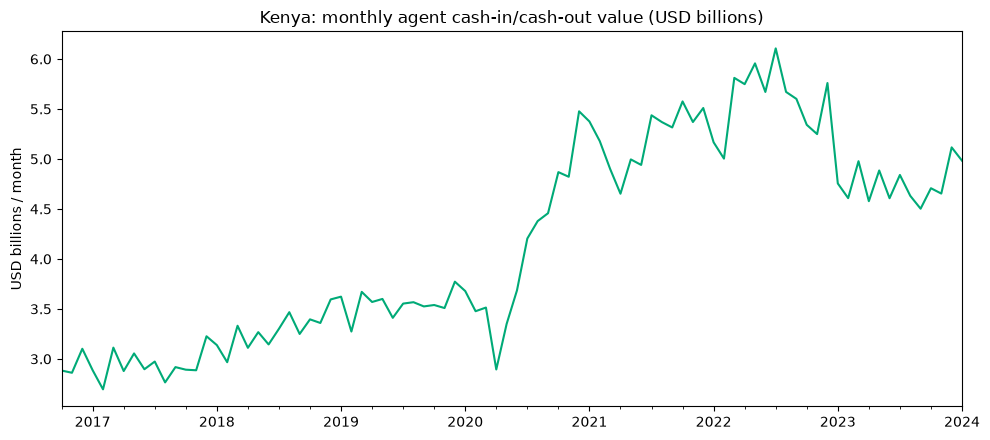

In [2]:
cico_usd = con.execute("""
    with monthly_usd as (
        select d.month_start, avg(f.kes_per_unit_mean) as kes_per_usd
        from gold.fact_exchange_rate f
        join gold.dim_date d using (date_key)
        where f.currency_code = 'USD'
        group by 1
    )
    select
        d.calendar_date                                   as month,
        m.agent_cico_value_ksh_billions,
        u.kes_per_usd,
        m.agent_cico_value_ksh_billions / u.kes_per_usd   as cico_usd_billions
    from gold.fact_mobile_money m
    join gold.dim_date d using (date_key)
    join monthly_usd u on u.month_start = d.calendar_date
    order by 1
""").fetchdf()

ax = cico_usd.plot(x="month", y="cico_usd_billions", legend=False, color="#0a7")
ax.set_title("Kenya: monthly agent cash-in/cash-out value (USD billions)")
ax.set_ylabel("USD billions / month")
ax.set_xlabel("")
plt.tight_layout()

latest = cico_usd.dropna().iloc[-1]
annual_run_rate = cico_usd.dropna().tail(12)["cico_usd_billions"].sum()
print(f"Latest month with FX coverage: {latest['month']:%Y-%m}: "
      f"${latest['cico_usd_billions']:.2f}B")
print(f"Trailing-12-month agent CICO value: ${annual_run_rate:.1f}B")

## 2. Account ownership: is East Africa converging on Kenya?

World Bank Findex: share of adults (15+) with an account at a financial institution
**or** mobile-money provider.

country_name  Kenya  Rwanda  Tanzania  Uganda
year                                         
2011           42.3    32.8      17.3    20.5
2014           74.7    42.1      39.8    44.4
2017           81.6    50.0      46.8    59.2
2021           79.2     NaN      52.4    65.9
2024           90.1     NaN      59.8    72.8


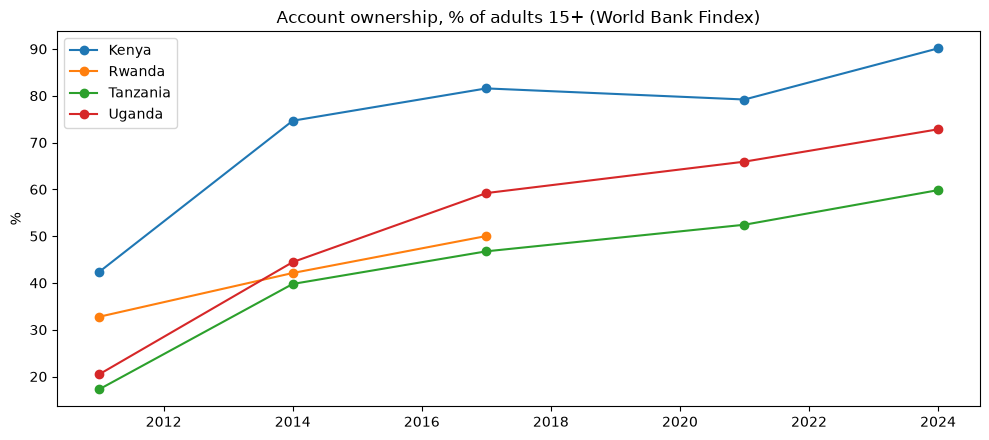

In [3]:
ownership = con.execute("""
    select w.year, c.country_name, w.value
    from gold.fact_worldbank_indicator w
    join gold.dim_country c using (country_iso3)
    where w.indicator_code = 'FX.OWN.TOTL.ZS'
    order by 1
""").fetchdf()

pivot = ownership.pivot(index="year", columns="country_name", values="value")
ax = pivot.plot(marker="o")
ax.set_title("Account ownership, % of adults 15+ (World Bank Findex)")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(title=None)
plt.tight_layout()
print(pivot.round(1).to_string())

## 3. Saturation: accounts kept growing, agents did too — value per agent didn't

Registered accounts now exceed Kenya's adult population (multiple SIMs/wallets per
person), so growth in *accounts* stopped being informative years ago; the agent
network is the physical cash frontier.

2007-03: 0.02M accounts, 307 agents
2026-05: 94.1M accounts, 564330 agents


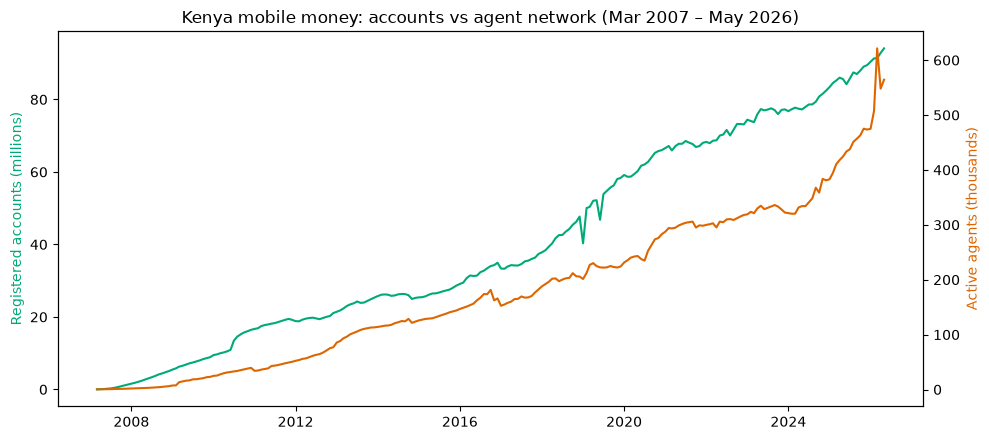

In [4]:
saturation = con.execute("""
    select
        d.calendar_date as month,
        m.registered_accounts_millions,
        m.active_agents / 1000.0 as active_agents_thousands
    from gold.fact_mobile_money m
    join gold.dim_date d using (date_key)
    order by 1
""").fetchdf()

fig, ax1 = plt.subplots()
ax1.plot(saturation["month"], saturation["registered_accounts_millions"], color="#0a7")
ax1.set_ylabel("Registered accounts (millions)", color="#0a7")
ax2 = ax1.twinx()
ax2.plot(saturation["month"], saturation["active_agents_thousands"], color="#d60")
ax2.set_ylabel("Active agents (thousands)", color="#d60")
ax1.set_title("Kenya mobile money: accounts vs agent network (Mar 2007 – May 2026)")
plt.tight_layout()

first, last = saturation.iloc[0], saturation.iloc[-1]
print(f"{first['month']:%Y-%m}: {first['registered_accounts_millions']:.2f}M accounts, "
      f"{first['active_agents_thousands']*1000:.0f} agents")
print(f"{last['month']:%Y-%m}: {last['registered_accounts_millions']:.1f}M accounts, "
      f"{last['active_agents_thousands']*1000:.0f} agents")